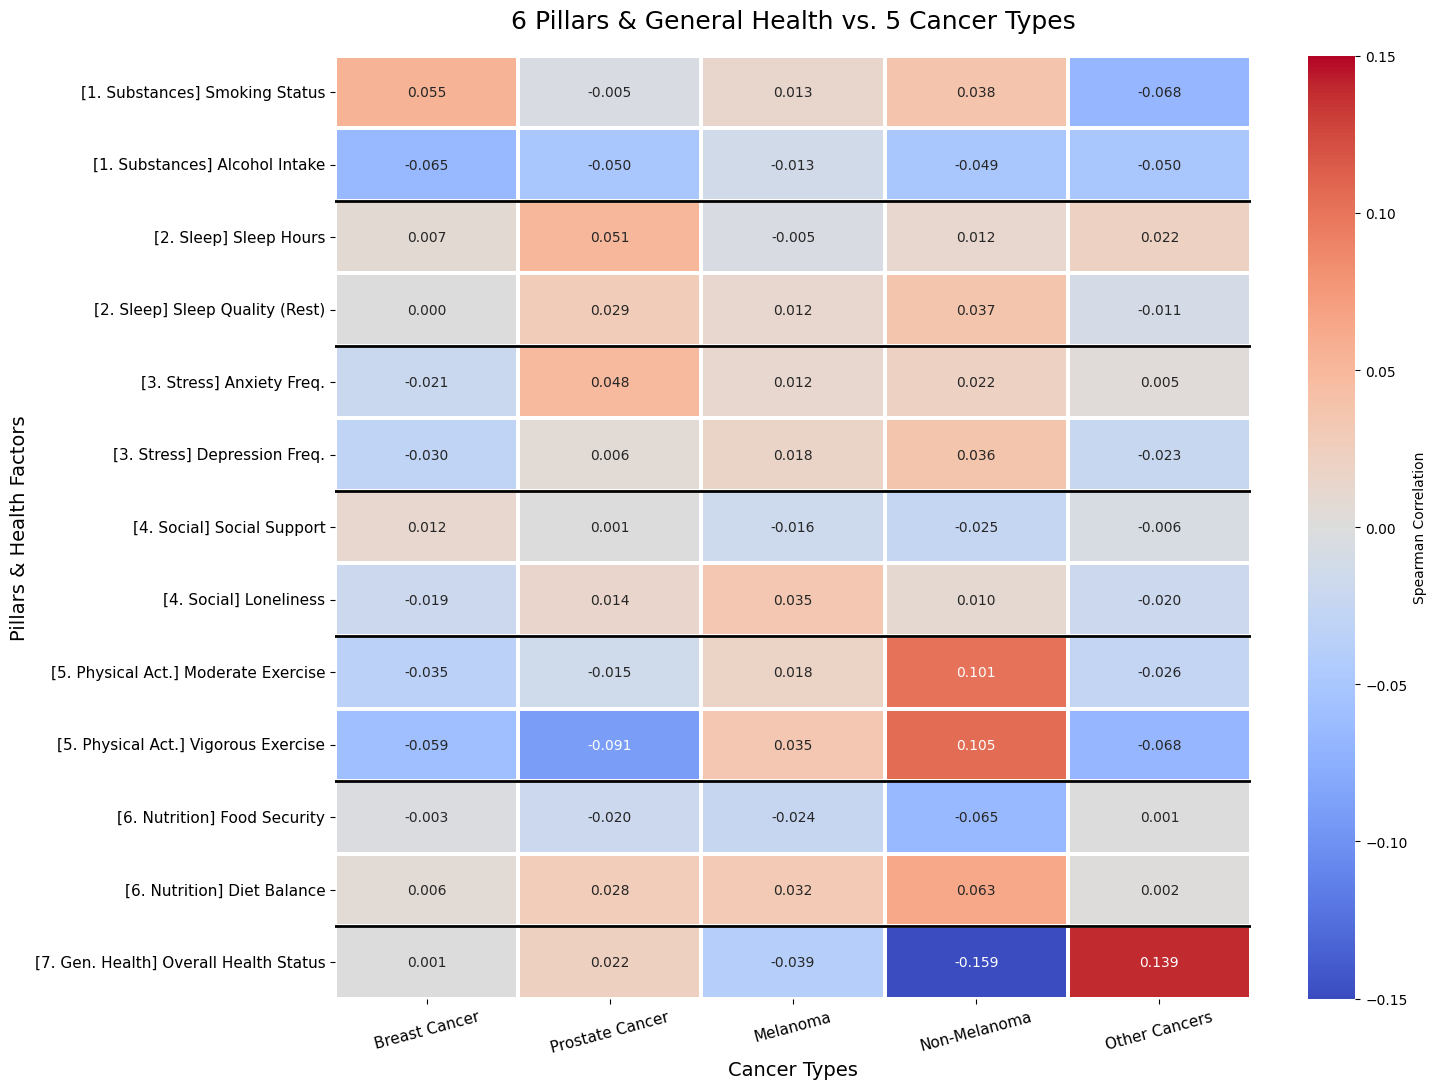


완벽하게 수정되었습니다! '6_pillars_plus_health_correlation.png' 파일이 생성되었습니다.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
df = pd.read_csv('final_nhis_data_mice_imputed_corrected.csv')

# 타겟 암 변수 설정 및 전처리 (2.0 -> 0.0)
cancer_targets = ['BREASCAN_A', 'PROSTCAN_A', 'SKNMCAN_A', 'SKNNMCAN_A', 'Merged_Other_Cancer']

for col in cancer_targets:
    if col in df.columns:
        df[col] = df[col].replace({2.0: 0.0})

# 2. 6 Pillars + PHSTAT_A(주관적 건강 상태) 변수명 딕셔너리 구성
pillars = {
    '1. Substances': {
        'SMKCIGST_A': 'Smoking Status',
        'DRKAVG12M_A': 'Alcohol Intake'
    },
    '2. Sleep': {
        'SLPHOURS_A': 'Sleep Hours',
        'SLPREST_A': 'Sleep Quality (Rest)'
    },
    '3. Stress': {
        'ANXFREQ_A': 'Anxiety Freq.',
        'DEPFREQ_A': 'Depression Freq.'
    },
    '4. Social': {
        'SUPPORT_A': 'Social Support',
        'LONELY_A': 'Loneliness'
    },
    '5. Physical Act.': {
        'MODFREQW_A': 'Moderate Exercise',
        'VIGFREQW_A': 'Vigorous Exercise'
    },
    '6. Nutrition': {
        'FDSCAT3_A': 'Food Security',
        'FDSBALANCE_A': 'Diet Balance'
    },
    '7. Gen. Health': {
        'PHSTAT_A': 'Overall Health Status' # 추가된 변수
    }
}

# 3. 히트맵 데이터 프레임 구성
all_lifestyle_vars = []
y_labels = []
line_positions = []
current_pos = 0

for pillar, vars_dict in pillars.items():
    for var, name in vars_dict.items():
        all_lifestyle_vars.append(var)
        y_labels.append(f"[{pillar}] {name}")
        current_pos += 1
    # 각 Pillar가 끝나는 위치 저장 (구분선을 그리기 위함)
    line_positions.append(current_pos)

# Spearman 상관계수 계산
corr_matrix = df[all_lifestyle_vars + cancer_targets].corr(method='spearman')
target_corr = corr_matrix.loc[all_lifestyle_vars, cancer_targets]

# X축 암 이름 예쁘게 변경
target_corr.columns = ['Breast Cancer', 'Prostate Cancer', 'Melanoma', 'Non-Melanoma', 'Other Cancers']
target_corr.index = y_labels

# ==========================================
# 4. 히트맵 시각화
# ==========================================
plt.figure(figsize=(15, 11))
ax = sns.heatmap(target_corr, annot=True, cmap='coolwarm', center=0, 
                 vmin=-0.15, vmax=0.15, fmt=".3f", linewidths=1.5, 
                 cbar_kws={'label': 'Spearman Correlation'})

plt.title('6 Pillars & General Health vs. 5 Cancer Types', fontsize=18, pad=20)
plt.ylabel('Pillars & Health Factors', fontsize=14)
plt.xlabel('Cancer Types', fontsize=14)
plt.xticks(rotation=15, fontsize=11)
plt.yticks(fontsize=11)

# 히트맵에 Pillar(기둥) 구분을 위한 가로선 추가
# 마지막 줄(맨 아래)에는 선을 그을 필요가 없으므로 제외([:-1])
for pos in line_positions[:-1]:
    ax.axhline(pos, color='black', lw=2)

plt.tight_layout()
plt.savefig('6_pillars_plus_health_correlation.png', dpi=300)
plt.show()
